### We will be performing all the necessary machine learning operations !

In [116]:
### Importing all the necessary libraries 

import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, precision_score, recall_score, confusion_matrix, recall_score, accuracy_score, ConfusionMatrixDisplay,f1_score, roc_auc_score
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import seaborn as sns

In [64]:
### Dataset we will be using 
data = pd.read_csv('../Datasets/formodel.csv')
data.drop(columns="Unnamed: 0", inplace = True)
data.head(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,1,0,29.85,29.85,0
1,1,0,0,0,34,1,0,0,1,0,1,0,0,0,1,0,1,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,1,1,0,0,0,0,0,1,1,53.85,108.15,1
3,1,0,0,0,45,0,0,0,1,0,1,1,0,0,1,0,2,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,0,70.70,151.65,1


### Since we have alrady done the feature engineering and correctd the datatypes and filled the missing values, we are directly moving to the model creation. 

In [65]:
### Lets see the distribution of the y class
print(data['Churn'].value_counts())

Churn
0    5163
1    1869
Name: count, dtype: int64


In [66]:
## Splitting the data into train test split 
RANDOM_SEED = 42
X = data.drop(columns = 'Churn')
y = data['Churn']
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state= 42)

### Model One: Logistic Regression 

In [67]:
pipeline_steps = [('scaler',StandardScaler()),('logit_model',LogisticRegression(class_weight='balanced', random_state=RANDOM_SEED))]
logit_pipeline = Pipeline(pipeline_steps)

###As there is high class imbalance we will be using class_weight = 'balanced' and the StratifiedKFold to address the issue

params = {'logit_model__C':[0.01,0.1,1,10,100], 'logit_model__penalty':['l1','l2']}

### Hyperparameter tuning
kf = StratifiedKFold(n_splits=5,shuffle=True, random_state=RANDOM_SEED)
logit_model = GridSearchCV(logit_pipeline, param_grid = params, cv = kf)
tuned_model = logit_model.fit(X_train,y_train)
logit_model = tuned_model.best_estimator_

/opt/anaconda3/envs/customer_churn/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/envs/customer_churn/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/envs/customer_churn/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and w

In [68]:
logit_testing_pred = logit_model.predict(X_test)
logit_training_pred = logit_model.predict(X_train)

logit_testing_proba = logit_model.predict_proba(X_test)
logit_training_proba = logit_model.predict_proba(X_train)



### Metrics for the calcuation of the model performance 

Logit Testing Accuracy Score: 0.73
Logit Training Accuracy Score: 0.75
Precision Score: 0.50
Recall Score: 0.80
F1-Score: 0.61
Logit False Positive Rate: 0.29
Logit False Negative Rate: 0.20
Logit ROC-AUC score: 0.75


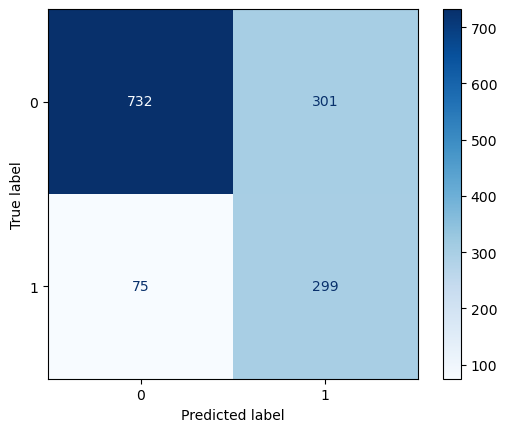

In [69]:
## Accuracy Score calculation
logit_testing_accruacy = accuracy_score(y_test, logit_testing_pred)
print(f"Logit Testing Accuracy Score: {logit_testing_accruacy:.2f}")
logit_training_accuracy = accuracy_score(y_train, logit_training_pred)
print(f"Logit Training Accuracy Score: {logit_training_accuracy:.2f}")


logit_precision = precision_score(y_test, logit_testing_pred)
print(f"Precision Score: {logit_precision:.2f}")

logit_recall = recall_score(y_test,logit_testing_pred)
print(f"Recall Score: {logit_recall:.2f}")

logit_f1 = f1_score(y_test, logit_testing_pred)
print(f"F1-Score: {logit_f1:.2f}")

logit_matrix = confusion_matrix(y_test, logit_testing_pred)
true_negatives, false_positives, false_negatives, true_positives = confusion_matrix(y_test, logit_testing_pred ).ravel()

logit_false_positive_rate = (false_positives)/(true_negatives+false_positives) 
print(f"Logit False Positive Rate: {logit_false_positive_rate:.2f}")
logit_false_negative_rate = (false_negatives)/(true_positives+false_negatives)
print(f"Logit False Negative Rate: {logit_false_negative_rate:.2f}")
logit_confusion = confusion_matrix(y_test, logit_testing_pred)

logit_roc_score = roc_auc_score(y_test,logit_testing_pred)
print(f"Logit ROC-AUC score: {logit_roc_score:.2f}")
display = ConfusionMatrixDisplay(confusion_matrix = logit_confusion)
display.plot(cmap='Blues')
plt.show()



### Model 2: Naive Bayes Classifier 

In [70]:
naive_model = GaussianNB(var_smoothing=1e-9)
naive_model.fit(X_train,y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [71]:
naive_testing_pred = naive_model.predict(X_test)
naive_training_pred = naive_model.predict(X_train)

naive_testing_proba = naive_model.predict_proba(X_test)
naive_training_proba = naive_model.predict_proba(X_train)

Logit Testing Accuracy Score: 0.74
Logit Training Accuracy Score: 0.76
Precision Score: 0.51
Recall Score: 0.72
F1-Score: 0.60
Naive Bayes False Positive Rate: 0.24
Naive Bayes False Negative Rate: 0.28
Naive Bayes ROC-AUC score: 0.74


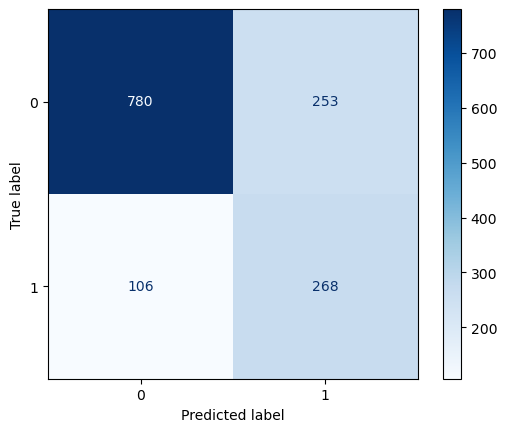

In [72]:
## Accuracy Score calculation
naive_testing_accruacy = accuracy_score(y_test, naive_testing_pred)
print(f"Logit Testing Accuracy Score: {naive_testing_accruacy:.2f}")
naive_training_accuracy = accuracy_score(y_train, naive_training_pred)
print(f"Logit Training Accuracy Score: {naive_training_accuracy:.2f}")

## Precsion score 

naive_precision = precision_score(y_test, naive_testing_pred)
print(f"Precision Score: {naive_precision:.2f}")

### Recall score 

naive_recall = recall_score(y_test,naive_testing_pred)
print(f"Recall Score: {naive_recall:.2f}")

## F1 Score 

naive_f1 = f1_score(y_test, naive_testing_pred)
print(f"F1-Score: {naive_f1:.2f}")

## Confusion Matrix 


naive_matrix = confusion_matrix(y_test, naive_testing_pred)
true_negatives, false_positives, false_negatives, true_positives = confusion_matrix(y_test, naive_testing_pred ).ravel()

### False Positive and False Negative Rate 


naive_false_positive_rate = (false_positives)/(true_negatives+false_positives) 
print(f"Naive Bayes False Positive Rate: {naive_false_positive_rate:.2f}")
naive_false_negative_rate = (false_negatives)/(true_positives+false_negatives)
print(f"Naive Bayes False Negative Rate: {naive_false_negative_rate:.2f}")

## Roc Score of the model


naive_roc_score = roc_auc_score(y_test,naive_testing_pred)
print(f"Naive Bayes ROC-AUC score: {naive_roc_score:.2f}")


### Plotting the confusion matrix 
display = ConfusionMatrixDisplay(confusion_matrix = naive_matrix)
display.plot(cmap='Blues')
plt.show()







---

### Linear SVM Model 

In [73]:
pipeline_steps = [('scaler', StandardScaler()),('svm', LinearSVC(loss= 'hinge', class_weight='balanced', random_state=RANDOM_SEED))]
svm_model = Pipeline(pipeline_steps)

### Hyperparmeter tuning for linear svm model 

params = {'svm__C':[1e-4, 1e-3, 1e-2, 1e-1, 1,10,100]}
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
hyperparameters = GridSearchCV(svm_model, cv = kf, param_grid=params )

## Linear model selection 

hyperparameters.fit(X_train,y_train)

best_svm = hyperparameters.best_estimator_


/opt/anaconda3/envs/customer_churn/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/envs/customer_churn/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/envs/customer_churn/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/envs/customer_churn/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/envs/customer_churn/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/envs/customer_churn/

In [74]:
svm_testing_pred = best_svm.predict(X_test)
svm_training_pred = best_svm.predict(X_train)

svm_testing_proba = best_svm.decision_function(X_test)
svm_training_proba = best_svm.decision_function(X_train)

Linear SVM Testing Accuracy Score: 0.72
Linear SVM Training Accuracy Score: 0.75
Precision Score: 0.48
Recall Score: 0.50
F1-Score: 0.49
SVM ROC-AUC score: 0.65
SVM False Positive Rate: 0.20
SVM False Negative Rate: 0.50


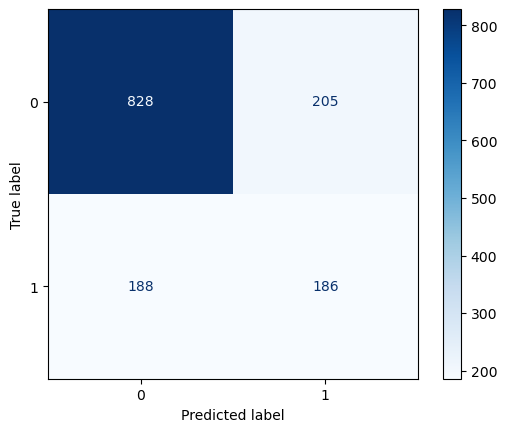

In [75]:
### Evaluation of the model's performance. 

## Accuracy Score calculation
svm_testing_accruacy = accuracy_score(y_test, svm_testing_pred)
print(f"Linear SVM Testing Accuracy Score: {svm_testing_accruacy:.2f}")
svm_training_accuracy = accuracy_score(y_train, svm_training_pred)
print(f"Linear SVM Training Accuracy Score: {svm_training_accuracy:.2f}")


### Model's precision 

## Precsion score 

svm_precision = precision_score(y_test, svm_testing_pred)
print(f"Precision Score: {svm_precision:.2f}")

### Recall score 

svm_recall = recall_score(y_test,svm_testing_pred)
print(f"Recall Score: {svm_recall:.2f}")

## F1 Score 

svm_f1 = f1_score(y_test, svm_testing_pred)
print(f"F1-Score: {svm_f1:.2f}")

## SVM Roc Score
svm_roc_score = roc_auc_score(y_test,svm_testing_pred)
print(f"SVM ROC-AUC score: {svm_roc_score:.2f}")

#Confusion Matrix 


svm_matrix = confusion_matrix(y_test, svm_testing_pred)
true_negatives, false_positives, false_negatives, true_positives = confusion_matrix(y_test, svm_testing_pred ).ravel()

# False Positive and False Negative Rate 


svm_false_positive_rate = (false_positives)/(true_negatives+false_positives) 
print(f"SVM False Positive Rate: {svm_false_positive_rate:.2f}")
svm_false_negative_rate = (false_negatives)/(true_positives+false_negatives)
print(f"SVM False Negative Rate: {svm_false_negative_rate:.2f}")

#Plotting the confusion matrix 
display = ConfusionMatrixDisplay(confusion_matrix = svm_matrix)
display.plot(cmap='Blues')
plt.show()


### Model 4: Decision Tree Classifier 

In [76]:
model = DecisionTreeClassifier(criterion='gini')
params = {'max_depth':[5,6,8,9,10], 'min_samples_split':[70,80,90,100], 'min_samples_leaf':[210,220,230,250], 'max_features':['log2',6,7,8 ]}
cv = StratifiedKFold(shuffle=True,n_splits=5, random_state=RANDOM_SEED)
model_tuning = GridSearchCV(model, cv = kf, param_grid=params)
model_tuning.fit(X_train, y_train)
decision_model = model_tuning.best_estimator_



### Checking the significance of each feature in the classification

In [77]:
feature_data = pd.DataFrame({'features':X.columns, 'score':list(decision_model.feature_importances_)})
feature_data = feature_data.sort_values(by = 'score', ascending=False)
feature_data.head()


,features,score
4,tenure,0.435584
17,MonthlyCharges,0.331741
14,Contract,0.150888
18,TotalCharges,0.051824
15,PaperlessBilling,0.016754


### Checking the model's performance

In [78]:
decision_testing_pred = decision_model.predict(X_test)
decision_training_pred = decision_model.predict(X_train)

decision_testing_proba = decision_model.predict_proba(X_test)
decision_training_proba = decision_model.predict_proba(X_train)

### Metrics for model's evaluation

Decision Tree Testing Accuracy Score: 0.78
Decision Tree Training Accuracy Score: 0.79
Precision Score: 0.61
Recall Score: 0.48
F1 Score: 0.54
Decision False Positive Rate: 0.11
Decision False Negative Rate: 0.52
Decision Tree ROC-AUC score: 0.69


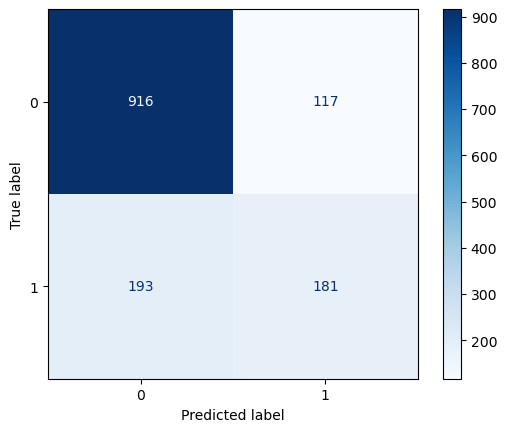

In [79]:
## Accuracy Score calculation
decision_testing_accruacy = accuracy_score(y_test, decision_testing_pred)
print(f"Decision Tree Testing Accuracy Score: {decision_testing_accruacy:.2f}")
decision_training_accuracy = accuracy_score(y_train, decision_training_pred)
print(f"Decision Tree Training Accuracy Score: {decision_training_accuracy:.2f}")


## Precison score 

decision_precision = precision_score(y_test, decision_testing_pred)
print(f"Precision Score: {decision_precision:.2f}")

## Recall Score
decision_recall = recall_score(y_test,decision_testing_pred)
print(f"Recall Score: {decision_recall:.2f}")

## F1-Score

decision_f1 = f1_score(y_test, decision_testing_pred)
print(f"F1 Score: {decision_f1:.2f}")
 
#Confusion Matrix 


decision_matrix = confusion_matrix(y_test, decision_testing_pred)
true_negatives, false_positives, false_negatives, true_positives = confusion_matrix(y_test, decision_testing_pred ).ravel()



decision_false_positive_rate = (false_positives)/(true_negatives+false_positives) 
print(f"Decision False Positive Rate: {decision_false_positive_rate:.2f}")
decision_false_negative_rate = (false_negatives)/(true_positives+false_negatives)
print(f"Decision False Negative Rate: {decision_false_negative_rate:.2f}")


decision_roc_score = roc_auc_score(y_test,decision_testing_pred)
print(f"Decision Tree ROC-AUC score: {decision_roc_score:.2f}")
display = ConfusionMatrixDisplay(confusion_matrix = decision_matrix)
display.plot(cmap='Blues')
plt.show()


# False Positive and False Negative Rate 


### Model 5: Random Forest Classifier 

In [80]:
random_model = RandomForestClassifier(criterion='gini', n_estimators= 300, random_state=RANDOM_SEED, oob_score= True)

### Calculating the best n_estimators 

n_estimators = [100,200,250, 300,400]
oob_score = []
for n in n_estimators:
    model = RandomForestClassifier(criterion='gini', random_state=RANDOM_SEED, n_estimators=n, oob_score= True)
    model.fit(X_train,y_train)

## By calculation we figured out that 300 has better oob score compared to others. 

In [81]:
params = {'max_features': [2,3,'log2','sqrt', 6], 'max_depth':[5,6,7,8,9], 'min_samples_split':[40, 50,60,70], 'min_samples_leaf':[150,160,170,180]}

kf = StratifiedKFold(shuffle=True, n_splits = 5, random_state=RANDOM_SEED)
model_tuning = GridSearchCV(random_model, param_grid=params, cv = kf)

model_tuning.fit(X_train,y_train)

random_model = model_tuning.best_estimator_



In [82]:
### Evaluating the best features 
feature_data = pd.DataFrame({'features':X.columns, 'score':list(random_model.feature_importances_)})
feature_data = feature_data.sort_values(by = 'score', ascending=False)
feature_data.head()


,features,score
14,Contract,0.329018
4,tenure,0.207457
17,MonthlyCharges,0.128224
16,PaymentMethod,0.105167
18,TotalCharges,0.083331


### Metrics for model evaluation 



In [83]:
random_testing_pred = random_model.predict(X_test)
random_training_pred = random_model.predict(X_train)

random_testing_proba = random_model.predict_proba(X_test)
ranodm_training_proba = random_model.predict_proba(X_train)

Random Forest Testing Accuracy Score: 0.79
Random Forest Training Accuracy Score: 0.80
Precision Score: 0.68
Recall Score: 0.39
F1 Score: 0.49
Random False Positive Rate: 0.07
Random False Negative Rate: 0.61
Random Forest ROC-AUC score: 0.66


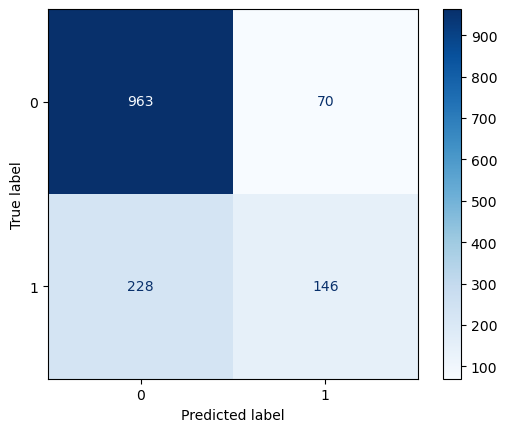

In [84]:
## Accuracy Score calculation
random_testing_accruacy = accuracy_score(y_test, random_testing_pred)
print(f"Random Forest Testing Accuracy Score: {random_testing_accruacy:.2f}")
random_training_accuracy = accuracy_score(y_train, random_training_pred)
print(f"Random Forest Training Accuracy Score: {random_training_accuracy:.2f}")

### Precison score 
random_precision = precision_score(y_test, random_testing_pred)
print(f"Precision Score: {random_precision:.2f}")

### Recall Score
random_recall = recall_score(y_test, random_testing_pred)
print(f"Recall Score: {random_recall:.2f}")

## F1-Score

random_f1 = f1_score(y_test, random_testing_pred)
print(f"F1 Score: {random_f1:.2f}")


## Confusion Matrix 

random_matrix = confusion_matrix(y_test, random_testing_pred)
true_negatives, false_positives, false_negatives, true_positives = confusion_matrix(y_test, random_testing_pred ).ravel()


### False Positive Rate and False Negative Rate 

random_false_positive_rate = (false_positives)/(true_negatives+false_positives) 
print(f"Random False Positive Rate: {random_false_positive_rate:.2f}")
random_false_negative_rate = (false_negatives)/(true_positives+false_negatives)
print(f"Random False Negative Rate: {random_false_negative_rate:.2f}")


random_roc_score = roc_auc_score(y_test,random_testing_pred)
print(f"Random Forest ROC-AUC score: {random_roc_score:.2f}")

display = ConfusionMatrixDisplay(confusion_matrix = random_matrix)
display.plot(cmap='Blues')
plt.show()



### Model 6: XGBClassifier

In [85]:
model = xgb.XGBClassifier(learning_rate = 0.1)

params = {'n_estimators':[200,300,400,500],'colsample_by_tree':[0.3,0.4,0.5,0.6], 'max_depth':[5,6,7,8], 'sub_sample':[0.5,0.6,0.7]}
cv = StratifiedKFold(n_splits = 5,shuffle = True,  random_state=RANDOM_SEED)
xgb_tuned = GridSearchCV(model, cv = kf, param_grid=params)
xgb_tuned.fit(X_train,y_train)
best_model = xgb_tuned.best_estimator_



/opt/anaconda3/envs/customer_churn/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [08:12:35] WARNING: /Users/ec2-user/croot/xgboost-split_1772031718290/work/src/learner.cc:782: 
Parameters: { "colsample_by_tree", "sub_sample" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/envs/customer_churn/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [08:12:35] WARNING: /Users/ec2-user/croot/xgboost-split_1772031718290/work/src/learner.cc:782: 
Parameters: { "colsample_by_tree", "sub_sample" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/envs/customer_churn/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [08:12:35] WARNING: /Users/ec2-user/croot/xgboost-split_1772031718290/work/src/learner.cc:782: 
Parameters: { "colsample_by_tree", "sub_sample" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/envs/customer_churn/lib/python3.12/site-packages/xgboost/trainin

In [86]:
### Checking out the feature importance 

feature_data = pd.DataFrame({'features':X.columns, 'score':list(best_model.feature_importances_)})
feature_data = feature_data.sort_values(by = 'score', ascending=False)
feature_data.head()

,features,score
14,Contract,0.458784
7,InternetService,0.097050
4,tenure,0.039360
8,OnlineSecurity,0.035294
11,TechSupport,0.033799


In [87]:
#### Calculating the metrics of the model evaluation 
xgb_testing_pred = best_model.predict(X_test)
xgb_training_pred = best_model.predict(X_train)

xgb_testing_proba = best_model.predict_proba(X_test)
xgb_training_proba = best_model.predict_proba(X_train)


Random Forest Testing Accuracy Score: 0.78
Random Forest Training Accuracy Score: 0.88
Precision Score: 0.60
Recall Score: 0.51
F1 Score: 0.55
Random False Positive Rate: 0.12
Random False Negative Rate: 0.49
XGB ROC-AUC score: 0.69


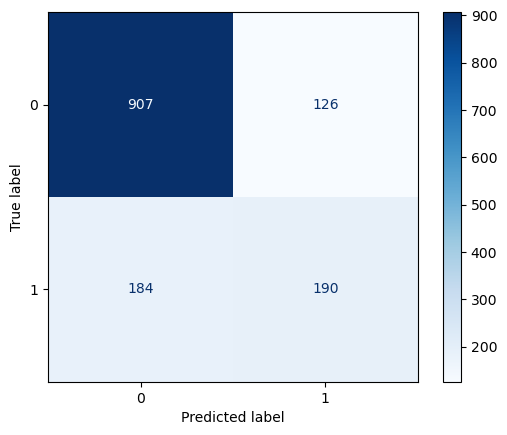

In [88]:
## Accuracy Score calculation
xgb_testing_accruacy = accuracy_score(y_test, xgb_testing_pred)
print(f"Random Forest Testing Accuracy Score: {xgb_testing_accruacy:.2f}")
xgb_training_accuracy = accuracy_score(y_train, xgb_training_pred)
print(f"Random Forest Training Accuracy Score: {xgb_training_accuracy:.2f}")

### Precison score 
xgb_precision = precision_score(y_test, xgb_testing_pred)
print(f"Precision Score: {xgb_precision:.2f}")

### Recall Score
xgb_recall = recall_score(y_test, xgb_testing_pred)
print(f"Recall Score: {xgb_recall:.2f}")


### F1-score
xgb_f1 = f1_score(y_test, xgb_testing_pred)
print(f"F1 Score: {xgb_f1:.2f}")


xgb_matrix = confusion_matrix(y_test, xgb_testing_pred)
true_negatives, false_positives, false_negatives, true_positives = confusion_matrix(y_test, xgb_testing_pred ).ravel()

### False Positive Rate and False Negative Rate 

xgb_false_positive_rate = (false_positives)/(true_negatives+false_positives) 
print(f"Random False Positive Rate: {xgb_false_positive_rate:.2f}")
xgb_false_negative_rate = (false_negatives)/(true_positives+false_negatives)
print(f"Random False Negative Rate: {xgb_false_negative_rate:.2f}")

xgb_roc_score = roc_auc_score(y_test,xgb_testing_pred)
print(f"XGB ROC-AUC score: {xgb_roc_score:.2f}")

display = ConfusionMatrixDisplay(confusion_matrix = xgb_matrix)
display.plot(cmap='Blues')
plt.show()




### Here we have evaluated all the models. It is time for selecting the best model out of all the 6 models tested so far

---
### Best Model Evaluation 

In [97]:
### Creating the dataset of the metrics on which model were evaluated

model_training_accuracy = [logit_training_accuracy, svm_training_accuracy, naive_training_accuracy, decision_training_accuracy, random_training_accuracy, xgb_training_accuracy]

model_testing_accuracy = [logit_testing_accruacy, svm_testing_accruacy, naive_testing_accruacy, decision_testing_accruacy, random_testing_accruacy, xgb_testing_accruacy]

## Model's precision 

model_precision = [logit_precision, svm_precision, naive_precision,decision_precision, random_precision, xgb_precision] 

## Model's recall

model_recall = [logit_recall, svm_recall, naive_recall, decision_recall, random_recall, xgb_recall]

### Model's F1-score

model_f1 = [logit_f1, svm_f1, naive_f1, decision_f1, random_f1, xgb_f1]

### Model's fpr 

model_fpr = [logit_false_positive_rate, svm_false_positive_rate, naive_false_positive_rate, decision_false_positive_rate, random_false_positive_rate, xgb_false_positive_rate]

### Model's fnr 

model_fnr = [logit_false_negative_rate ,svm_false_negative_rate, naive_false_negative_rate, decision_false_negative_rate, random_false_negative_rate, xgb_false_negative_rate]


### Model's Roc Score 

model_roc = [logit_roc_score, svm_roc_score, naive_roc_score, decision_roc_score, random_roc_score, xgb_roc_score]


models = ['logit', 'svm', 'naive', 'decisiontrees', 'randomforest', 'xgb']




In [120]:
model_performance = pd.DataFrame({
    'models':models, 
    'training_acc':model_training_accuracy,
    'testing_acc':model_testing_accuracy,
    'precision':model_precision,
    'recall':model_recall,
    'f1':model_f1,
    'fpr':model_fpr,
    'fnr':model_fnr,
    'roc-score':model_roc
})

model_performance.head(5)

,models,training_acc,testing_acc,precision,recall,f1,fpr,fnr,roc-score
0,logit,0.754489,0.732765,0.498333,0.799465,0.613963,0.291384,0.200535,0.754040
1,svm,0.753778,0.720682,0.475703,0.497326,0.486275,0.198451,0.502674,0.649438
2,naive,0.763911,0.744847,0.514395,0.716578,0.598883,0.244918,0.283422,0.735830
3,decisiontrees,0.785422,0.779673,0.607383,0.483957,0.538690,0.113262,0.516043,0.685347
4,randomforest,0.802133,0.788202,0.675926,0.390374,0.494915,0.067764,0.609626,0.661305


In [121]:
### Changing the structure of the dataset for the analysis of the model ! 

columns = ['training_acc', 'testing_acc', 'precision', 'recall', 'f1', 'fpr', 'fnr', 'roc-score']
model_performance[columns] = model_performance[columns] * 100

model_performance.head(5)

,models,training_acc,testing_acc,precision,recall,f1,fpr,fnr,roc-score
0,logit,75.448889,73.276475,49.833333,79.946524,61.396304,29.138432,20.053476,75.404046
1,svm,75.377778,72.068230,47.570332,49.732620,48.627451,19.845111,50.267380,64.943754
2,naive,76.391111,74.484719,51.439539,71.657754,59.888268,24.491772,28.342246,73.582991
3,decisiontrees,78.542222,77.967306,60.738255,48.395722,53.869048,11.326234,51.604278,68.534744
4,randomforest,80.213333,78.820185,67.592593,39.037433,49.491525,6.776379,60.962567,66.130527


### Plotting all the values in the combined bar chart

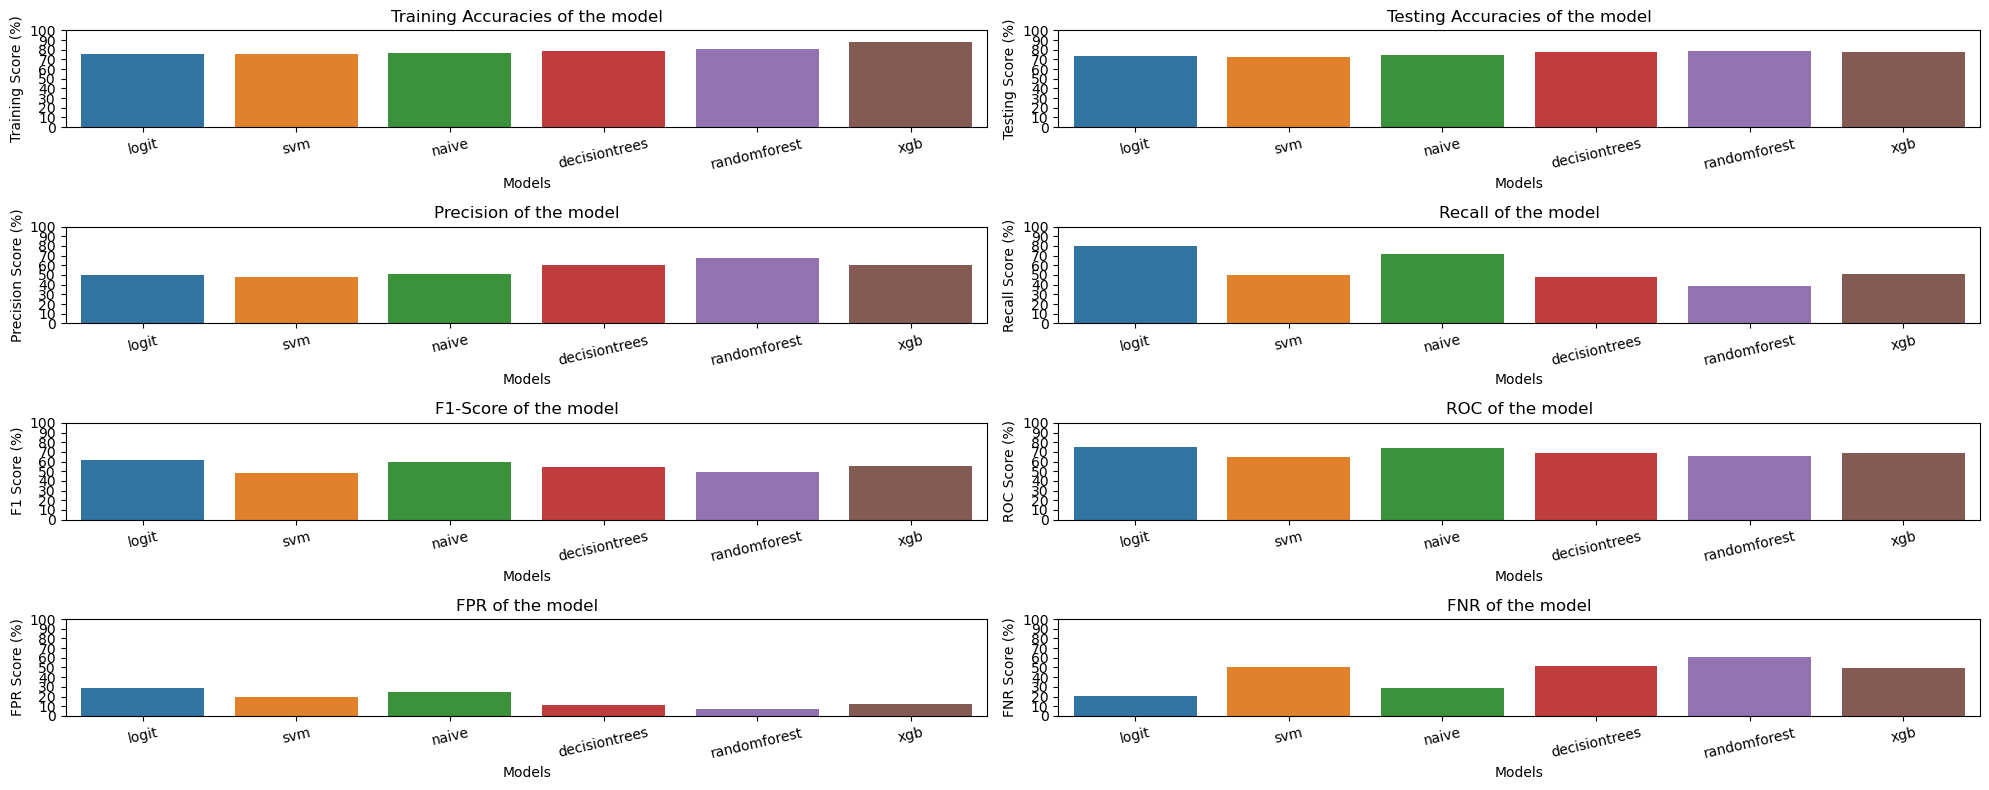

In [140]:
fig, ax = plt.subplots(4,2,figsize = (20,8))
def metrics_plotting(x, y , data, title, xlabel, ylabel, axes):
    sns.barplot(x = x, y = y , data = data,hue= x, ax = axes)
    axes.set_xlabel(xlabel)
    axes.set_ylabel(ylabel)
    axes.set_title(title)
    axes.set_ylim(0, 100)
    axes.set_yticks(np.arange(0,110,10))
    axes.tick_params(axis='x', rotation=13)
    plt.tight_layout()
    

metrics_plotting('models', 'training_acc', model_performance, 'Training Accuracies of the model', 'Models', 'Training Score (%)', ax[0][0])

metrics_plotting('models', 'testing_acc', model_performance, 'Testing Accuracies of the model', 'Models', 'Testing Score (%)', ax[0][1])

metrics_plotting('models', 'precision', model_performance, 'Precision of the model', 'Models', 'Precision Score (%)', ax[1][0])

metrics_plotting('models', 'recall', model_performance, 'Recall of the model', 'Models', 'Recall Score (%)', ax[1][1])

metrics_plotting('models', 'f1', model_performance, 'F1-Score of the model', 'Models', 'F1 Score (%)', ax[2][0])

metrics_plotting('models', 'roc-score', model_performance, 'ROC of the model', 'Models', 'ROC Score (%)', ax[2][1])

metrics_plotting('models', 'fpr', model_performance, 'FPR of the model', 'Models', 'FPR Score (%)', ax[3][0])

metrics_plotting('models', 'fnr', model_performance, 'FNR of the model', 'Models', 'FNR Score (%)', ax[3][1])
